In [1]:
from pipeline_functions import *

import numpy as np

import snntorch.spikeplot as splt
import snntorch as snn
from snntorch import functional as SF

import matplotlib.pyplot as plt

import torch
import torch.nn as nn

seed = 42

#sets seed for random to 42
np.random.seed(seed)
torch.manual_seed(seed) 

torch.use_deterministic_algorithms(True)

# sets device for tensors and model
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

Using device: cpu


In [2]:
X = np.empty((8, 307, 99000), dtype=np.float32)
y = np.empty((99000,), dtype=np.float32)
# loads data for all 55 subjects and preprocesses it
x_idx, y_idx = 0, 0
for num_subj in range(55): #WARNING, very long!
    file_name = f"C:/Users/crims/Desktop/Senior Design Code/datasets/Won2022_BIDS/.mat_files/s{num_subj+1:02d}.mat"
    # print(f"Loading {file_name}")
    X_subj, y_subj, time = fn_preprocess.preprocess_training(file_name)

    epoch_num = X_subj.shape[2]
    y_len = y_subj.shape[0]
    
    X[:, :, x_idx:x_idx+epoch_num] = X_subj.astype(np.float32, copy=False)
    y[y_idx:y_idx+y_len] = y_subj.astype(np.float32, copy=False)

    x_idx += epoch_num
    y_idx += y_len

    print(f"Subject {num_subj+1} loaded. Size: {X_subj.shape}")

assert x_idx == X.shape[2]
assert y_idx == y.shape[0]

print(X.shape)
print(X.dtype)
print(y.shape)

Subject 1 loaded. Size: (8, 307, 1800)
Subject 2 loaded. Size: (8, 307, 1800)
Subject 3 loaded. Size: (8, 307, 1800)
Subject 4 loaded. Size: (8, 307, 1800)
Subject 5 loaded. Size: (8, 307, 1800)
Subject 6 loaded. Size: (8, 307, 1800)
Subject 7 loaded. Size: (8, 307, 1800)
Subject 8 loaded. Size: (8, 307, 1800)
Subject 9 loaded. Size: (8, 307, 1800)
Subject 10 loaded. Size: (8, 307, 1800)
Subject 11 loaded. Size: (8, 307, 1800)
Subject 12 loaded. Size: (8, 307, 1800)
Subject 13 loaded. Size: (8, 307, 1800)
Subject 14 loaded. Size: (8, 307, 1800)
Subject 15 loaded. Size: (8, 307, 1800)
Subject 16 loaded. Size: (8, 307, 1800)
Subject 17 loaded. Size: (8, 307, 1800)
Subject 18 loaded. Size: (8, 307, 1800)
Subject 19 loaded. Size: (8, 307, 1800)
Subject 20 loaded. Size: (8, 307, 1800)
Subject 21 loaded. Size: (8, 307, 1800)
Subject 22 loaded. Size: (8, 307, 1800)
Subject 23 loaded. Size: (8, 307, 1800)
Subject 24 loaded. Size: (8, 307, 1800)
Subject 25 loaded. Size: (8, 307, 1800)
Subject 2

(16500, 307)
(82500, 307)


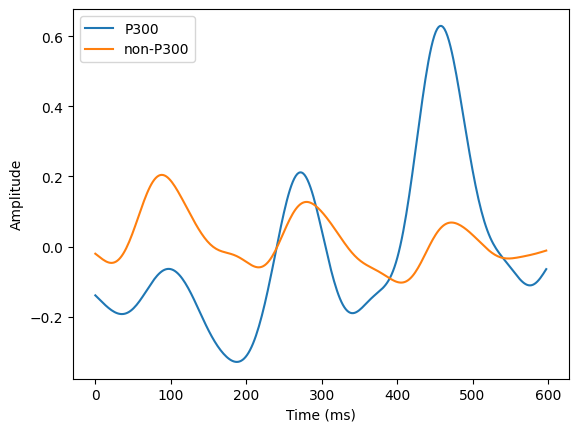

In [3]:
p300_trials = X[3, :, y == 1]
non_p300_trials = X[3, :, y == 0]
print(p300_trials.shape)
print(non_p300_trials.shape)

avg_P300 = p300_trials.mean(axis=0)
avg_non_P300 = non_p300_trials.mean(axis=0)

time = np.arange(avg_P300.shape[0]) / 512 * 1000

plt.plot(time, avg_P300, label='P300')
plt.plot(time, avg_non_P300, label='non-P300')
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.legend()

X shape: (99000, 8, 307)
Shape after feature extraction: (99000, 8, 17)


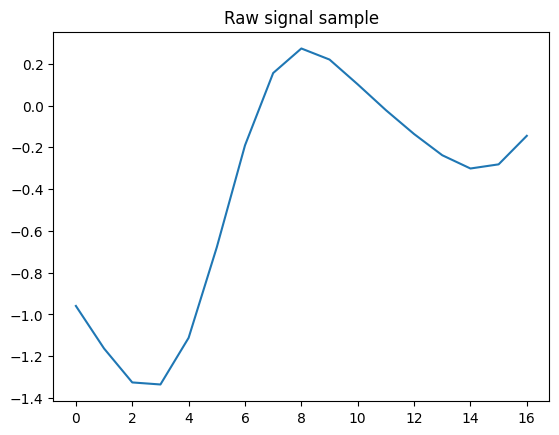

In [81]:
X_fe, y_fe = fn_feature_extraction.extractFeatures(X, y, k=1, t_min=200, t_max=400, norm_type='std', factor=6)

plt.plot(X_fe[0, 0, :])  # trial 0, channel 0
plt.title("Raw signal sample")
plt.show()

Average spike rate across all neurons and trials: 0.3760351307189542
[ 1  0  0  0 -1 -1 -1  0  0  0  0  0  1  0  0  0 -1]


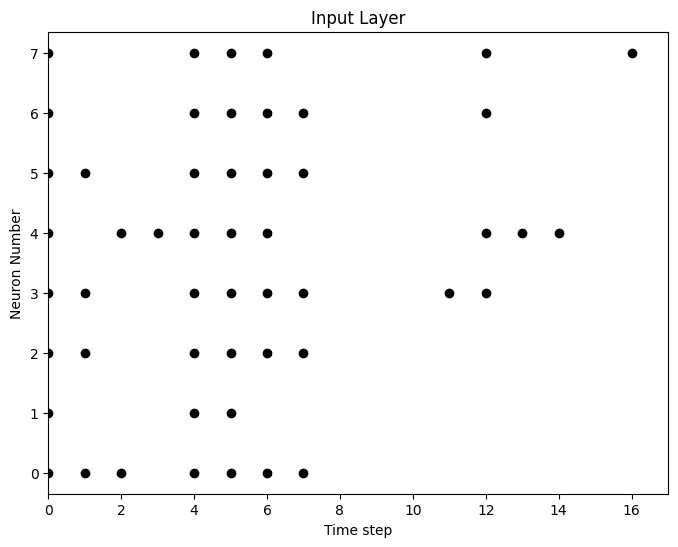

In [82]:
X_encoded = delta_encoding.delta_encode(X_fe, threshold=0.15) #spike encoding to implement

# total spikes across time, neurons, and trials
num_spikes = np.sum((np.abs(X_encoded) == 1))

# total number of "neuron-timesteps" across all trials
total_elements = X_encoded.size

avg_spike_rate = num_spikes / total_elements
print("Average spike rate across all neurons and trials:", avg_spike_rate)

# Create fig, ax
fig = plt.figure(facecolor="w", figsize=(8, 6))
ax = fig.add_subplot(111)

print(X_encoded[0, :, 7])
trial_spikes = torch.from_numpy(X_encoded[0, :, :])

# Raster plot of delta converted data
splt.raster(trial_spikes, ax, c="black")

plt.title("Input Layer")
plt.xlabel("Time step")
plt.ylabel("Neuron Number")
plt.xlim(0, X_encoded.shape[1])
plt.show()


In [86]:
# rerun from here for complete determinism and to avoid reloading and preprocessing data
data = X_encoded

batch_size = 256
y_fe = y_fe.astype(np.int64)

num_features = data.shape[2]
print(num_features)

train_loader, val_loader, test_loader, class_weights = train.prepare_training_data(data, y_fe, batch_size=batch_size, balanced=False)

8
Train size: 69300, Val size: 14850, Test size: 14850
Training Class Counts:  tensor([57695, 11605])
Training Class Weights: tensor([0.3349, 1.6651])


In [87]:
hidden_layer = [256, 128]
betas = [.95, .95, .95]
thresholds = torch.tensor([1, 1, 1])
torch.manual_seed(seed) # for reproducibility of model initialization

snn = SNNModule.createSNN(num_features, hidden_layer=hidden_layer, betas=betas, thresholds=thresholds, sigmoid_slope=10)

In [88]:
num_epochs = 10
lr = 5e-4

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
#criterion = SF.mse_count_loss(correct_rate=0.9, incorrect_rate=0.1)
print(class_weights.dtype)
optimizer = torch.optim.Adam(snn.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

update_every = 1 # will not change results, just prints updates divisible by this number

snn.to(device)

checkpoint_path = 'C:\\Users\\crims\\Desktop\\Senior Design Code\\VirtualKeyboard\\model_weights\\noavg3'

history = train.train(model=snn, num_epochs=num_epochs, train_loader=train_loader, val_loader=val_loader,
                      criterion=criterion, optimizer=optimizer, scheduler = scheduler, device=device, loss_style='spk', update_every=update_every,
                      checkpoint_path=None, batch_first=True)

torch.float32
Epoch 1: Training Loss: 0.6765, Training Accuracy: 55.31%, Training Balanced Accuracy: 57.56%, 
    Validation Loss: 0.6691, Validation Accuracy: 63.23%, Validation Balanced Accuracy: 58.72%
    Avg output spike rate: 0.4012
    Avg output membrane max: 11.0991
    Predictions for each class on Training Set: tensor([35793, 33507])
    Predictions for each class on Val Set: tensor([9293, 5557])
Epoch 2: Training Loss: 0.6690, Training Accuracy: 63.34%, Training Balanced Accuracy: 59.24%, 
    Validation Loss: 0.6691, Validation Accuracy: 64.39%, Validation Balanced Accuracy: 58.79%
    Avg output spike rate: 0.3766
    Avg output membrane max: 10.7694
    Predictions for each class on Training Set: tensor([43185, 26115])
    Predictions for each class on Val Set: tensor([9543, 5307])
Epoch 3: Training Loss: 0.6668, Training Accuracy: 63.73%, Training Balanced Accuracy: 59.77%, 
    Validation Loss: 0.6679, Validation Accuracy: 64.37%, Validation Balanced Accuracy: 58.91%
 

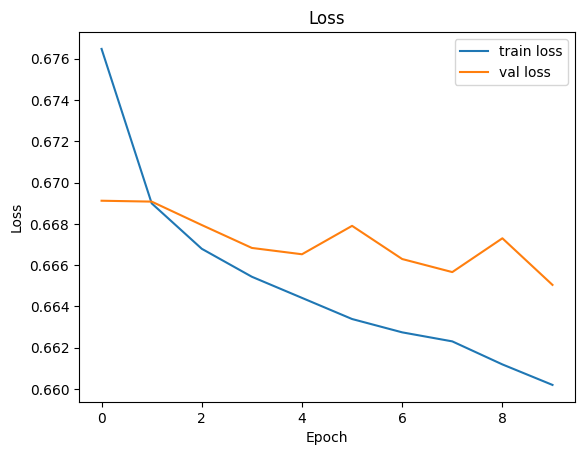

In [89]:
plt.plot(history['train_loss'], label='train loss')
plt.plot(history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

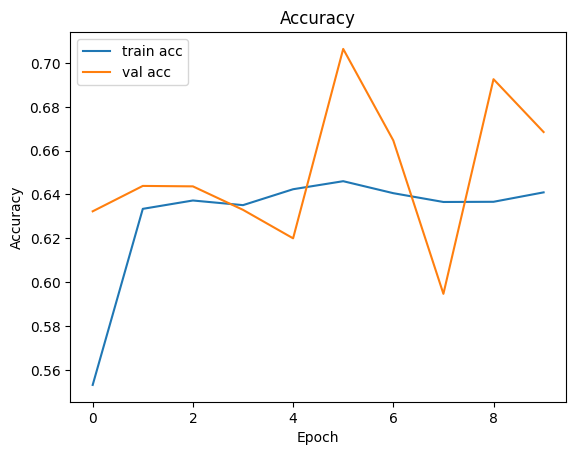

In [90]:
plt.plot(history['train_acc'], label='train acc')
plt.plot(history['val_acc'], label='val acc')
plt.legend()
plt.title("Accuracy")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

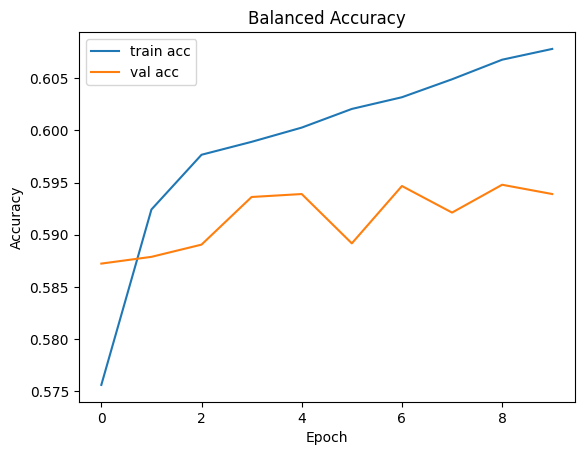

In [91]:
plt.plot(history['train_bal_acc'], label='train acc')
plt.plot(history['val_bal_acc'], label='val acc')
plt.legend()
plt.title("Balanced Accuracy")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

In [92]:
# testing on unseen test set
test_loss, test_acc, test_spk_rate, test_mem_max, test_pred_counts, test_bal_acc = train.validate_snn(snn, test_loader, criterion,
                                                                                        device=device, loss_style='spk', batch_first=True)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc*100:.2f}%, Test Balanced Accuracy: {test_bal_acc*100:.2f}%")
print(f"Avg output spike rate: {test_spk_rate:.4f}")
print(f"Avg output membrane max: {test_mem_max:.4f}")
print(f"Predictions for each class: {test_pred_counts}")

Test Loss: 0.6695, Test Accuracy: 66.24%, Test Balanced Accuracy: 58.32%
Avg output spike rate: 0.3897
Avg output membrane max: 12.3124
Predictions for each class: tensor([10003,  4847])


In [93]:
data, targets = next(iter(test_loader))
print(data.shape)
data, targets = data.to(device), targets.to(device)
with torch.no_grad():
    snn.eval()
    spk_rec, mem_rec = snn(data, batch_first=True)

spk_rec = spk_rec[:, 4, :]
mem_rec = mem_rec[:, 4, :]
#print(mem_rec)
print(spk_rec)
#print(mem_rec.shape)
print("Shape of output:", spk_rec.shape)
print("Sum of spikes for each output:", spk_rec.sum(axis=0))

torch.Size([256, 17, 8])
tensor([[0., 0.],
        [0., 0.],
        [0., 0.],
        [1., 0.],
        [0., 0.],
        [1., 0.],
        [0., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 1.],
        [1., 1.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.]])
Shape of output: torch.Size([17, 2])
Sum of spikes for each output: tensor([8., 2.])


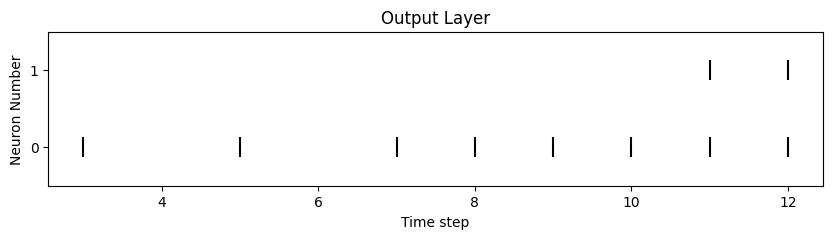

In [94]:
fig = plt.figure(facecolor="w", figsize=(10, 2))
ax = fig.add_subplot(111)

#  s: size of scatter points; c: color of scatter points
splt.raster(spk_rec, ax, s=200, c="black", marker='|')
plt.yticks([0, 1], ['0', '1'])
ax.set_ylim(-0.5, 1.5)
plt.title("Output Layer")
plt.xlabel("Time step")
plt.ylabel("Neuron Number")
plt.show()

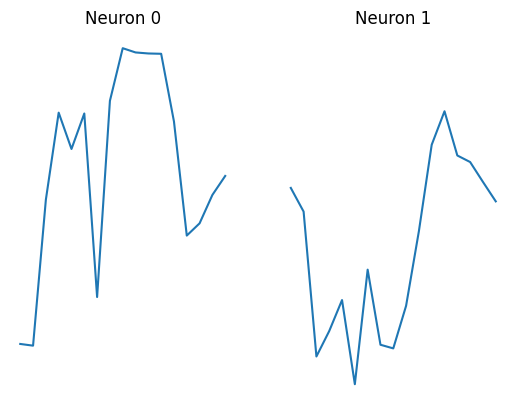

In [95]:
splt.traces(mem_rec, dim=(1, 2), titles=['Neuron 0', 'Neuron 1'])

In [96]:
model_weights = snn.state_dict()

weights_file_path = 'C:\\Users\\crims\\Desktop\\Senior Design Code\\VirtualKeyboard\\model_weights\\noavg3.pth'

torch.save(model_weights, weights_file_path)